### Importing Required Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns


In [32]:
cpi = pd.read_excel('data/CPI_By_Dec.xlsx')

In [33]:
cpi.head()

,cpi_total,food,non_food,paid_services
0,100.7,101.0,100.3,100.6
1,101.5,102.2,100.8,101.2
2,105.2,108.2,103.6,102.6
3,107.3,111.6,104.9,103.6
4,108.8,113.5,106.3,104.5


In [34]:
years = np.repeat([2022, 2023, 2024, 2025], 12)
months = list(range(1, 13)) * 4

cpi["year"] = years
cpi["month"] = months

In [35]:
cpi.head()

,cpi_total,food,non_food,paid_services,year,month
0,100.7,101.0,100.3,100.6,2022,1
1,101.5,102.2,100.8,101.2,2022,2
2,105.2,108.2,103.6,102.6,2022,3
3,107.3,111.6,104.9,103.6,2022,4
4,108.8,113.5,106.3,104.5,2022,5


In [36]:
cpi['date'] = pd.to_datetime(cpi['year'].astype(str)+'-'+cpi['month'].astype(str)+'-01')

In [37]:
cpi = cpi.sort_values(["year", "month"])

cpi["cpi_lag_1"]  = cpi["cpi_total"].shift(1)
cpi["cpi_lag_3"]  = cpi["cpi_total"].shift(3)
cpi["cpi_lag_12"] = cpi["cpi_total"].shift(12)

In [44]:
y = cpi['cpi_total']
X = cpi[['food','non_food','paid_services']]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [47]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = mlr.predict(X_test)
print(f"MLR intercept b0:{mlr.intercept_}")
print(f'MLR coefficients (w1,w2):{mlr.coef_}')


MLR intercept b0:-0.015003890698437772
MLR coefficients (w1,w2):[0.41395728 0.29783779 0.28835195]


### Error

In [53]:
print("MLR MSE:", mean_squared_error(y_test, y_pred))
print("MLR R2:", r2_score(y_test, y_pred))

MLR MSE: 0.001895689119413066
MLR R2: 0.9997755624740229


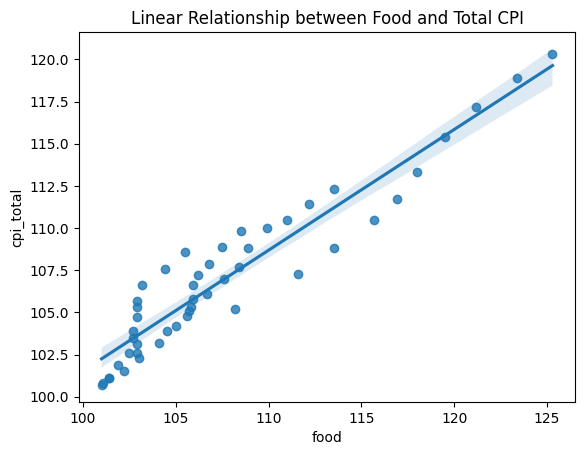

In [59]:
sns.regplot(x='food', y='cpi_total', data=cpi)
plt.title('Linear Relationship between Food and Total CPI')
plt.show()

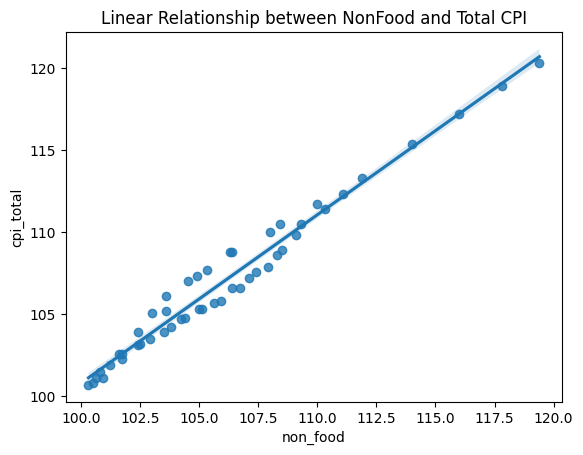

In [61]:
sns.regplot(x='non_food', y='cpi_total', data=cpi)
plt.title('Linear Relationship between NonFood and Total CPI')
plt.show()

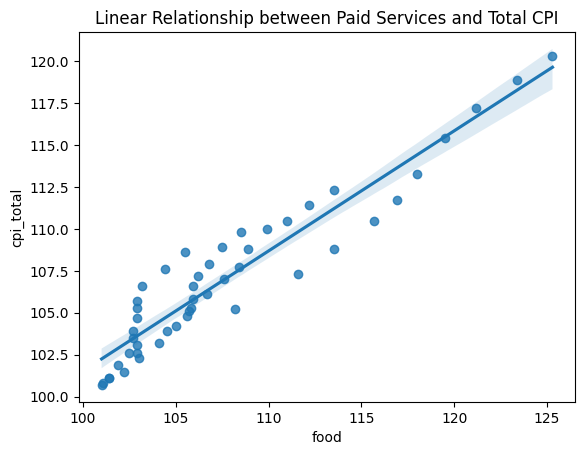

In [62]:
sns.regplot(x='food', y='cpi_total', data=cpi)
plt.title('Linear Relationship between Paid Services and Total CPI')
plt.show()